In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import os
import random
import shutil

In [2]:
# os.listdir()

In [3]:
# file1 = os.listdir("Cat")
# file2 = os.listdir("Dog")

In [4]:
# random.shuffle(file1)
# random.shuffle(file2)

In [5]:
# print(len(file1))
# print(len(file2))

In [6]:
# split = int(0.8 * len(file1))
# train_cats = file1[:split]
# test_cats = file1[split:]

In [7]:
# train_dogs = file2[:split]
# test_dogs = file2[split:]

In [8]:
# print(len(train_cats))
# print(len(test_cats))
# print(len(train_dogs))
# print(len(test_dogs))

In [9]:
# shutil.rmtree("data")

In [10]:
# os.makedirs('data/train/cats', exist_ok=True)# exist_ok doesnt throw error if folder already exist
# os.makedirs('data/test/cats', exist_ok=True)
# os.makedirs('data/train/dogs', exist_ok=True) 
# os.makedirs('data/test/dogs', exist_ok=True) 

In [11]:
# print(os.path.join("Cat", file1[0]))

In [12]:
# for cat in train_cats:
#     shutil.copy(os.path.join("Cat", cat), "data/train/cats")

In [13]:
# for cat in test_cats:
#     shutil.copy(os.path.join("Cat", cat), "data/test/cats")

In [14]:
# for dog in train_dogs:
#     shutil.copy(os.path.join("Dog", dog), "data/train/dogs")

In [15]:
# for dog in test_dogs:
#     shutil.copy(os.path.join("Dog", dog), "data/test/dogs")

In [16]:
# print(len(os.listdir("data/train/cats")))
# print(len(os.listdir("data/train/dogs")))
# print(len(os.listdir("data/test/cats")))
# print(len(os.listdir("data/test/dogs")))

In [17]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) 
])

In [18]:
train_set = datasets.ImageFolder("data/train", transform = transform)
test_set = datasets.ImageFolder("data/test", transform = transform)

In [19]:
train_data = DataLoader(train_set, batch_size=64,shuffle=True)
test_data = DataLoader(test_set, batch_size=64,)

In [20]:
print(train_set.classes)

['cats', 'dogs']


In [21]:
images, labels = next(iter(train_data)) # iter()-> turns dataloader to iterator, next()->grabs the first batch
print(images.shape)  # 32images in batch , 3channels(RGB) , 128x128 px

torch.Size([64, 3, 128, 128])


In [22]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv_layers = nn.Sequential(

            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc_layer = nn.Sequential(
            nn.Linear(16*16*128,256),
            nn.ReLU(),

            nn.Linear(256,2)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

In [23]:
model = CNN()
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [24]:
# from PIL import Image

# def check_images(folder):
#     for fname in os.listdir(folder):
#         fpath = os.path.join(folder, fname)
#         try:
#             img = Image.open(fpath)
#             img.verify()
#         except:
#             print(f"Removing: {fpath}")
#             os.remove(fpath)

# check_images("data/train/cats")
# check_images("data/train/dogs")
# check_images("data/test/cats")
# check_images("data/test/dogs")

In [25]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for idx,(images,labels) in enumerate(train_data):
        optimizer.zero_grad()
        if idx%50==0:
            print(f"Epoch {epoch+1},Batch {idx}/{len(train_data)}")
       
        outputs=model(images)
        ls = loss(outputs,labels)
        ls.backward()
        optimizer.step()
        running_loss += ls.item()

    print(f"epoch : {epoch+1}/{epochs} loss = {running_loss/len(train_data)}")

Epoch 1,Batch 0/313
Epoch 1,Batch 50/313
Epoch 1,Batch 100/313
Epoch 1,Batch 150/313
Epoch 1,Batch 200/313
Epoch 1,Batch 250/313
Epoch 1,Batch 300/313
epoch : 1/10 loss = 0.6355995771983942
Epoch 2,Batch 0/313
Epoch 2,Batch 50/313
Epoch 2,Batch 100/313
Epoch 2,Batch 150/313
Epoch 2,Batch 200/313
Epoch 2,Batch 250/313
Epoch 2,Batch 300/313
epoch : 2/10 loss = 0.5092914996627039
Epoch 3,Batch 0/313
Epoch 3,Batch 50/313
Epoch 3,Batch 100/313
Epoch 3,Batch 150/313
Epoch 3,Batch 200/313
Epoch 3,Batch 250/313
Epoch 3,Batch 300/313
epoch : 3/10 loss = 0.4400193354668328
Epoch 4,Batch 0/313
Epoch 4,Batch 50/313
Epoch 4,Batch 100/313
Epoch 4,Batch 150/313
Epoch 4,Batch 200/313
Epoch 4,Batch 250/313
Epoch 4,Batch 300/313
epoch : 4/10 loss = 0.36754360785499546
Epoch 5,Batch 0/313
Epoch 5,Batch 50/313
Epoch 5,Batch 100/313
Epoch 5,Batch 150/313
Epoch 5,Batch 200/313
Epoch 5,Batch 250/313
Epoch 5,Batch 300/313
epoch : 5/10 loss = 0.28327374167430897
Epoch 6,Batch 0/313
Epoch 6,Batch 50/313
Epoch 6

In [28]:
crt_pred = 0
orig     = 0

model.eval()
with torch.no_grad():
    for images,labels in test_data:
        outputs = model(images)
        _,predicted = torch.max(outputs,1)

        crt_pred += (predicted == labels).sum().item()
        orig += (labels.size(0))

print("Accuracy : ", (crt_pred/orig)*100)

C:\Users\rohit\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Accuracy :  79.875975195039


In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
all_preds = []
orig_labels = []

In [31]:
model.eval()
with torch.no_grad():
    for images,labels in test_data:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        orig_labels.extend(labels.numpy())

C:\Users\rohit\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


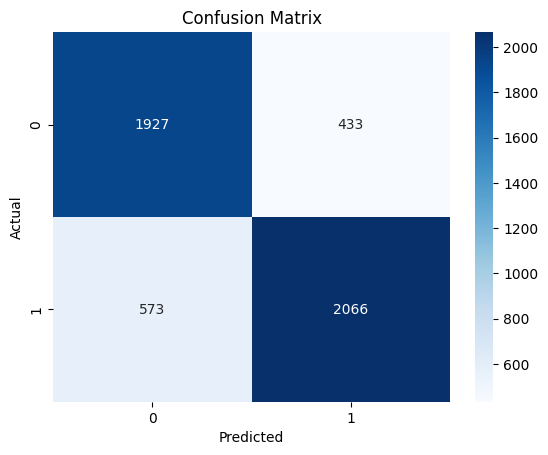

In [32]:
cm = confusion_matrix(all_preds,orig_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [35]:
torch.save(model.state_dict(), 'CTDG.pth')
print("Model saved!")

Model saved!


In [36]:
model = CNN()
model.load_state_dict(torch.load('CTDG.pth'))
model.eval()
print("Model loaded!")

Model loaded!


### Testing the model

In [37]:
from PIL import Image

In [39]:
img1 = Image.open("data/cat_test.jpg")

In [40]:
img1 = transform(img1)

In [41]:
print(img1.shape)

torch.Size([3, 128, 128])


In [43]:
img1=img1.unsqueeze(0)

In [44]:
model.eval()
with torch.no_grad():
    output = model(img1)
    _, predicted = torch.max(output, 1)
    print(predicted)

tensor([0])


In [45]:
print(train_set.classes)


['cats', 'dogs']


In [47]:
img2 = Image.open("data/dog_test.jpg")

In [48]:
img2 = transform(img2)

In [51]:
img2 = img2.unsqueeze(0)

In [52]:
model.eval()
with torch.no_grad():
    output = model(img2)
    _,predicted = torch.max(output,1)
    print(predicted)

tensor([1])
